# Detection de changement de couverture du sol

## Notebook de demonstration

Ce notebook presente de maniere simple un pipeline de detection de changement entre deux images d'une meme zone observee a deux dates differentes.

L'objectif est de montrer :
- comment les images sont comparees ;
- pourquoi certaines zones sont considerees comme modifiees ;
- quelles sont les limites de la methode.

Le code principal reste dans le dossier `src/`. Ce notebook sert surtout a expliquer et illustrer les etapes.

## Fil de presentation

Nous suivons les etapes suivantes :

1. Charger deux images de la meme zone.
2. Les preparer pour la comparaison.
3. Extraire des indicateurs simples lies a la vegetation et a la texture.
4. Construire une carte de changement.
5. Produire un masque final des zones detectees comme modifiees.
6. Conclure avec une lecture metier, puis une lecture plus technique.

In [10]:
from pathlib import Path
import sys

if (Path.cwd() / "src").exists():
    project_root = Path.cwd()
else:
    project_root = Path.cwd().parent

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

%matplotlib inline

import cv2
import numpy as np
import matplotlib.pyplot as plt

from io_utils import load_image
from preprocessing import basic_preprocessing
from features import green_ratio, rgb_to_gray, local_mean, local_variance, build_feature_stack


def normalize_map(x: np.ndarray) -> np.ndarray:
    x = x.astype(np.float32)
    return (x - x.min()) / (x.max() - x.min() + 1e-8)


def filter_small_components(mask: np.ndarray, min_size: int = 80) -> np.ndarray:
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    clean_mask = np.zeros_like(mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_size:
            clean_mask[labels == i] = 255
    return clean_mask


def show_side_by_side(img1, img2, title1, title2, cmap1=None, cmap2=None, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plt.subplot(1, 2, 1)
    plt.imshow(img1, cmap=cmap1)
    plt.title(title1)
    plt.axis("off")
    plt.subplot(1, 2, 2)
    plt.imshow(img2, cmap=cmap2)
    plt.title(title2)
    plt.axis("off")
    plt.show()


## 1. Images utilisees

Pour cette demonstration, on compare :
- `train_118_B.png` comme image de reference (`t0`) ;
- `train_118.png` comme image plus recente (`t1`).

Hypothese de travail : ces deux images representent la meme zone a deux dates differentes.

Pourquoi commencer par cette etape ?
Parce qu'avant toute analyse, il faut verifier visuellement que les deux images sont bien comparables.

Dimensions t0: (1024, 1024, 3)
Dimensions t1: (1024, 1024, 3)


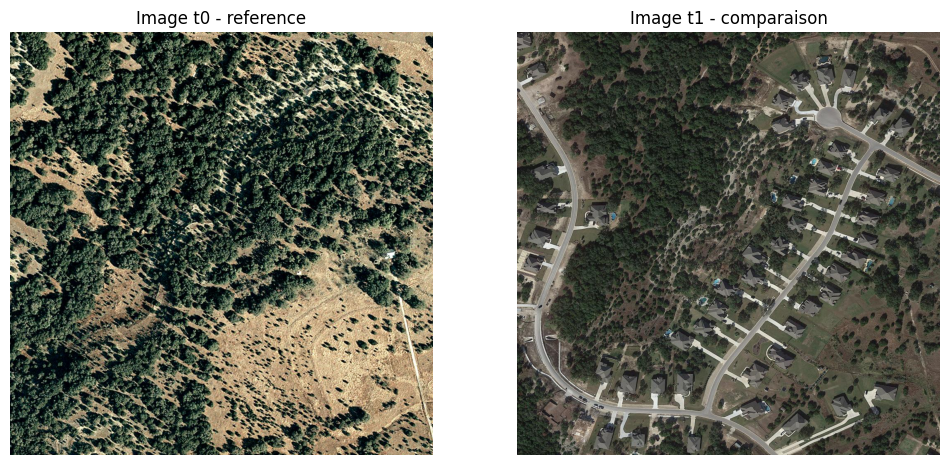

In [11]:
t0_path = project_root / "data" / "t0.png"
t1_path = project_root / "data" / "t1.png"

img_t0 = load_image(str(t0_path))
img_t1 = load_image(str(t1_path))

print("Dimensions t0:", img_t0.shape)
print("Dimensions t1:", img_t1.shape)

show_side_by_side(img_t0, img_t1, "Image t0 - reference", "Image t1 - comparaison")

**Interpretation**

Les deux images ont la meme dimension et paraissent tres proches visuellement. Cela suggere une scene globalement stable, sans changement massif evident a premiere vue.

## 2. Pretraitement

Avant de comparer les images, on applique un pretraitement leger.

Ce pretraitement a deux roles :
- reduire un peu le bruit ;
- mieux faire ressortir les details utiles.

Choix retenus dans le projet :
- un filtre median pour limiter le bruit ponctuel tout en preservant les contours des routes, des maisons et des zones vegetales ;
- une amelioration locale du contraste (CLAHE) pour mieux separer visuellement les zones sombres, les zones claires et les textures locales.

Justification de chaque etape :
- le filtre median est utile car il lisse legerement l'image sans flouter excessivement les frontieres entre les objets ;
- le contraste local est utile car deux zones proches peuvent avoir des niveaux de luminosite assez similaires, et cette etape aide a mieux faire ressortir leurs differences ;
- le pretraitement reste volontairement modere pour eviter de creer de faux changements entre `t0` et `t1`.

L'idee n'est donc pas de transformer l'image, mais de la rendre plus stable et plus lisible avant l'extraction des indicateurs.

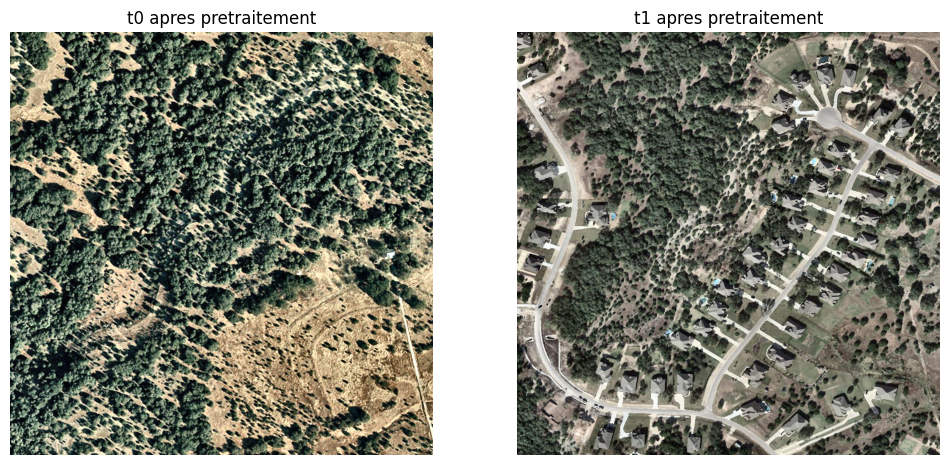

In [12]:
img_t0_prep = basic_preprocessing(img_t0, apply_denoise=True, apply_contrast=True)
img_t1_prep = basic_preprocessing(img_t1, apply_denoise=True, apply_contrast=True)

show_side_by_side(img_t0_prep, img_t1_prep, "t0 apres pretraitement", "t1 apres pretraitement")

**Interpretation**

Le pretraitement ameliore legerement la lisibilite locale sans modifier fortement la scene. Les contours et les structures principales restent coherents, ce qui est important pour comparer `t0` et `t1` sans introduire de faux ecarts.

## 3. Indicateurs utilises

La comparaison ne repose pas seulement sur les couleurs brutes.

Nous utilisons trois types d'informations :
- la couleur, en particulier le ratio de vert, utile pour reperer la vegetation ;
- la luminosite locale, avec la moyenne locale ;
- la texture locale, avec la variance locale.

Pourquoi ces indicateurs ?
Parce qu'un changement de couverture du sol ne se voit pas seulement par une difference de couleur, mais aussi par une difference de structure visuelle.

Justification simple :
- le ratio de vert sert de proxy de la vegetation ;
- la moyenne locale resume l'intensite moyenne autour d'un pixel ;
- la variance locale aide a distinguer les textures plus homogenes des textures plus heterogenes.

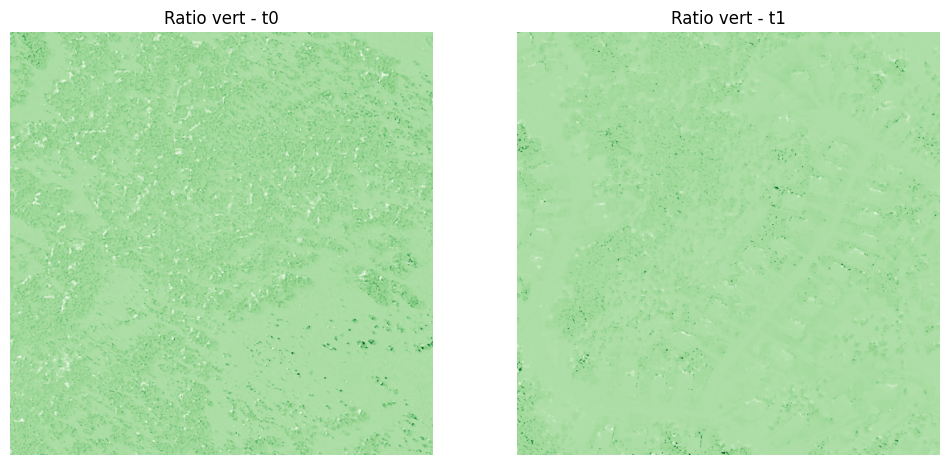

In [13]:
ratio_t0 = green_ratio(img_t0_prep)
ratio_t1 = green_ratio(img_t1_prep)

gray_t0 = rgb_to_gray(img_t0_prep)
gray_t1 = rgb_to_gray(img_t1_prep)

mean_t0 = local_mean(gray_t0, kernel_size=5)
mean_t1 = local_mean(gray_t1, kernel_size=5)

var_t0 = local_variance(gray_t0, kernel_size=5)
var_t1 = local_variance(gray_t1, kernel_size=5)

show_side_by_side(ratio_t0, ratio_t1, "Ratio vert - t0", "Ratio vert - t1", cmap1="Greens", cmap2="Greens")

**Interpretation**

Les cartes de ratio vert sont tres proches entre les deux dates. Cela va plutot dans le sens d'une stabilite globale de la couverture vegetale, avec au plus de faibles differences locales.

## 4. Construction de la carte de changement

On calcule ensuite, pour chaque pixel, l'ecart entre `t0` et `t1` sur plusieurs indicateurs.

Ces ecarts sont combines pour produire une carte de changement :
- plus la valeur est forte, plus le pixel semble avoir change ;
- plus la valeur est faible, plus la zone semble stable.

Dans ce projet, le ratio de vert a un poids plus important car il est tres utile pour distinguer les zones vegetales.

Un lissage leger est ensuite applique a la carte afin de reduire les petites variations isolees qui ne correspondent pas forcement a un changement reel.

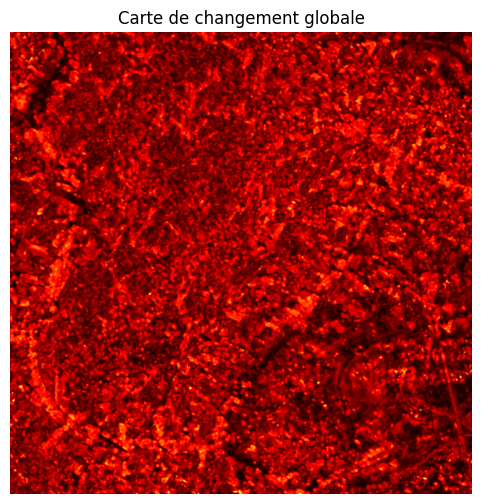

In [14]:
diff_ratio = normalize_map(np.abs(ratio_t1 - ratio_t0))
diff_mean = normalize_map(np.abs(mean_t1 - mean_t0))
diff_var = normalize_map(np.abs(var_t1 - var_t0))

change_map = 0.6 * diff_ratio + 0.2 * diff_mean + 0.2 * diff_var
change_map = cv2.GaussianBlur(change_map, (5, 5), 0)
change_map = normalize_map(change_map)

plt.figure(figsize=(6, 6))
plt.imshow(change_map, cmap="hot")
plt.title("Carte de changement globale")
plt.axis("off")
plt.show()

**Interpretation**

La carte de changement met en avant les zones ou les differences sont les plus fortes. Si les zones chaudes sont limitees, diffuses ou dispersees, cela traduit plutot de petites variations locales qu'un changement important a grande echelle.

## 5. Passage a un masque interpretable

Une carte de changement est informative, mais elle n'est pas toujours facile a lire pour un usage metier.

On la transforme donc en masque binaire :
- en blanc : zones considerees comme changees ;
- en noir : zones considerees comme stables.

On ajoute ensuite un nettoyage morphologique pour supprimer une partie du bruit et conserver les zones les plus coherentes.

Justification :
- le seuillage permet de passer d'une carte continue a une lecture simple change / stable ;
- l'ouverture et la fermeture morphologiques servent a enlever des petits artefacts et a regulariser les formes ;
- la suppression des petites composantes permet d'eviter d'interpreter comme changement des details trop petits ou parasites.

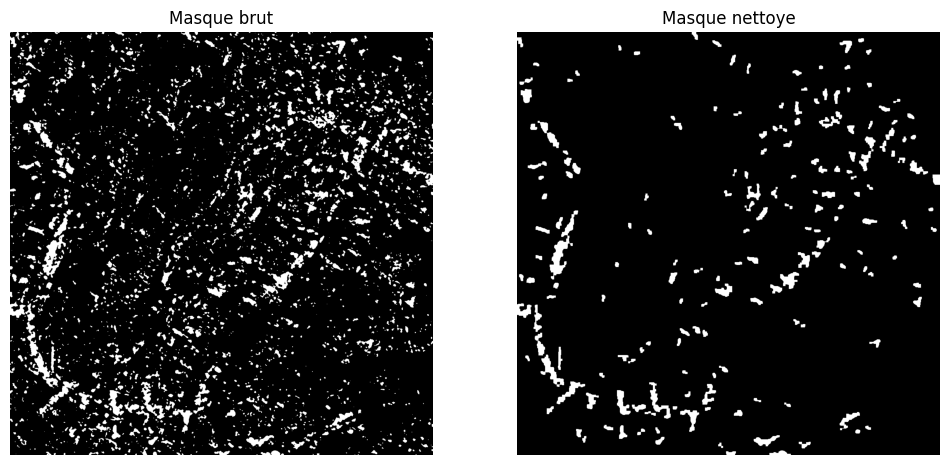

In [15]:
threshold = np.percentile(change_map, 90)
change_mask = (change_map > threshold).astype(np.uint8) * 255

kernel = np.ones((5, 5), np.uint8)
change_mask_clean = cv2.morphologyEx(change_mask, cv2.MORPH_OPEN, kernel)
change_mask_clean = cv2.morphologyEx(change_mask_clean, cv2.MORPH_CLOSE, kernel)
change_mask_clean = filter_small_components(change_mask_clean, min_size=80)

show_side_by_side(change_mask, change_mask_clean, "Masque brut", "Masque nettoye", cmap1="gray", cmap2="gray")

**Interpretation**

Le masque nettoye conserve seulement les zones finalement retenues comme potentiellement modifiees. Si ces zones restent peu nombreuses ou fragmentaires, il faut les lire avec prudence : elles peuvent correspondre a un faible changement reel, mais aussi a du bruit residuel.

## 6. Lecture metier du resultat

Le resultat final met en evidence les zones ou l'image recente semble differer de l'image de reference.

Dans le cas present, les deux images paraissent tres proches visuellement. On ne s'attend donc pas a observer un changement majeur et massif.


- si le masque detecte quelques zones, elles peuvent correspondre a de faibles differences locales ;
- elles peuvent aussi refleter des variations d'eclairage, de texture fine ou de pretraitement ;
- l'absence de changement net a grande echelle est ici une information importante en soi.

Autrement dit, ce pipeline sert d'outil d'aide a l'analyse : il permet soit de confirmer un changement visible, soit de montrer qu'aucun changement clair n'apparait entre les deux dates.

In [16]:
changed_pixels = int(np.sum(change_mask_clean > 0))
total_pixels = int(change_mask_clean.shape[0] * change_mask_clean.shape[1])
changed_ratio = changed_pixels / total_pixels

print("Pixels detectes comme modifies :", changed_pixels)
print(f"Proportion de changement : {changed_ratio:.4f}")

Pixels detectes comme modifies : 47511
Proportion de changement : 0.0453


## 7. Explication technique pour les questions plus data

Cette partie sert a repondre a des questions plus techniques pendant la presentation.

### Representation des donnees
- chaque image est lue comme un tableau numerique ;
- plusieurs cartes intermediaires sont calculees : ratio de vert, moyenne locale, variance locale ;
- ces cartes sont ensuite comparees entre `t0` et `t1`.

### Logique de la carte de changement
- on calcule une difference absolue pour chaque indicateur ;
- on normalise les cartes pour les rendre comparables ;
- on combine ces cartes avec une somme ponderee.

### Pourquoi ce choix de features ?
- le ratio de vert donne un signal utile sur la vegetation ;
- la moyenne locale resume l'intensite autour d'un pixel ;
- la variance locale capte davantage la texture.

### Limites techniques
- si les images sont mal alignees, le pipeline produit de faux changements ;
- si l'eclairage change fortement, la comparaison devient moins fiable ;
- le seuil final reste heuristique ;
- lorsque les deux images sont tres proches, une partie du masque peut correspondre a du bruit residuel plutot qu'a un changement significatif ;
- cette approche est interpretable, mais plus simple que des methodes d'apprentissage.

### Ou se trouve le code metier ?
- `src/io_utils.py` : lecture des images ;
- `src/preprocessing.py` : pretraitement ;
- `src/features.py` : extraction des indicateurs ;
- `src/main.py` : orchestration du pipeline.

Le notebook ne fait que piloter et commenter ces fonctions.

In [17]:
features_t0 = build_feature_stack(img_t0_prep, kernel_size=5)
features_t1 = build_feature_stack(img_t1_prep, kernel_size=5)

print("Shape feature stack t0:", features_t0.shape)
print("Shape feature stack t1:", features_t1.shape)

Shape feature stack t0: (1024, 1024, 9)
Shape feature stack t1: (1024, 1024, 9)


## Bilan de la Partie A

La Partie A met en place une lecture heuristique et progressive du changement entre les deux dates.

Elle montre bien que :
- les images apres pretraitement deviennent plus lisibles
- le ratio vert et les features locales font ressortir les zones potentiellement vegetalisees
- une carte de changement peut etre obtenue sans passer encore par une segmentation complete

Ce bilan est important car il fournit les indicateurs qui motivent ensuite la Partie B : passer d'une detection visuelle du changement a une quantification structuree de la vegetation.


## Transition vers la Partie B

La Partie A permet de localiser des changements probables, mais elle reste essentiellement heuristique.

La Partie B ajoute une etape plus structuree et plus proche d'un pipeline exploitable :
- segmentation par clustering
- selection automatique du cluster vegetation
- nettoyage morphologique des masques
- quantification finale de la vegetation avant et apres

L'objectif n'est donc plus seulement de voir le changement, mais de mesurer la vegetation de facon plus systematique.


In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
from PIL import Image as PILImage
from IPython.display import Markdown, display

ROOT = Path('..')
OUTPUTS = ROOT / 'outputs'
METRICS_PATH = OUTPUTS / 'metrics.json'

if not METRICS_PATH.exists():
    raise FileNotFoundError(f'Metrics file not found: {METRICS_PATH}')

with METRICS_PATH.open(encoding='utf-8') as f:
    metrics = json.load(f)


def load_rgb(rel_path):
    return PILImage.open(ROOT / rel_path).convert('RGB')


def show_pair(rel_left, rel_right, title_left, title_right, figsize=(9, 4.4)):
    left = load_rgb(rel_left)
    right = load_rgb(rel_right)
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    for ax, img, title in zip(axes, [left, right], [title_left, title_right]):
        ax.imshow(img)
        ax.set_title(title, fontsize=11)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


def show_single(rel_path, title, figsize=(7, 5.5)):
    image = load_rgb(rel_path)
    plt.figure(figsize=figsize)
    plt.imshow(image)
    plt.title(title, fontsize=11)
    plt.axis('off')
    plt.tight_layout()
    plt.show()


def show_title(text):
    display(Markdown(f'### {text}'))


### Images pretraitees utilisees pour la Partie B

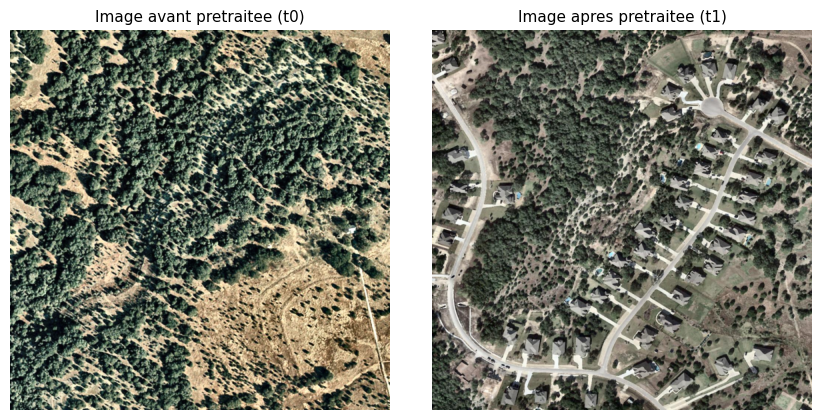

In [2]:
show_title('Images pretraitees utilisees pour la Partie B')
show_pair(
    'outputs/preprocessed_images/16_t0_preprocessed.png',
    'outputs/preprocessed_images/17_t1_preprocessed.png',
    'Image avant pretraitee (t0)',
    'Image apres pretraitee (t1)',
    figsize=(8.6, 4.2),
)


## Methode et justification de la Partie B

Le pipeline de segmentation utilise les features suivantes pour chaque pixel :
- RGB
- HSV
- ratio vert
- moyenne locale
- variance locale

**Justification**

Ces features ont ete retenues car elles sont complementaires :
- le RGB conserve l'information coloree de base
- le HSV separe mieux la teinte et l'intensite lumineuse
- le ratio vert aide a reperer la vegetation de facon plus robuste
- la moyenne locale et la variance locale ajoutent une information de texture et de structure

Le nombre de clusters est guide par une CAH sur un echantillon de pixels, puis un K-means est applique sur l'ensemble des pixels.

Ce choix est coherent dans un contexte de prototypage :
- la CAH aide a justifier le choix de `k`
- K-means reste simple, rapide et interpretable
- l'identification automatique du cluster vegetation evite une selection manuelle non justifiee


### Dendrogrammes de la CAH

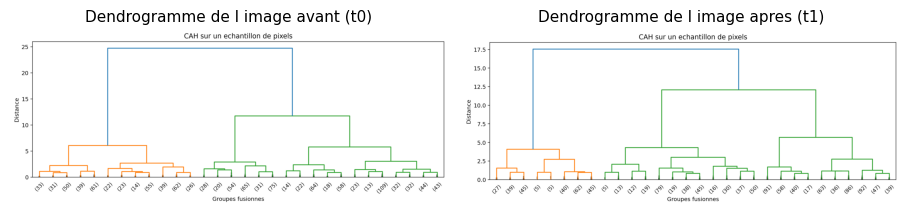

### Resultats de segmentation par K-means

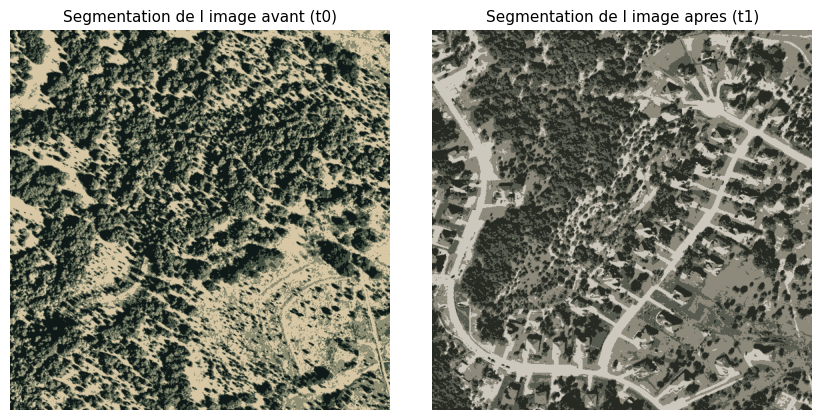

In [3]:
show_title('Dendrogrammes de la CAH')
show_pair(
    'outputs/dendrogram_t0.png',
    'outputs/dendrogram_t1.png',
    'Dendrogramme de l image avant (t0)',
    'Dendrogramme de l image apres (t1)',
    figsize=(9.2, 3.9),
)

show_title('Resultats de segmentation par K-means')
show_pair(
    'outputs/segmentation_t0.png',
    'outputs/segmentation_t1.png',
    'Segmentation de l image avant (t0)',
    'Segmentation de l image apres (t1)',
    figsize=(8.6, 4.2),
)


## Interpretation de la segmentation

Les dendrogrammes donnent une justification visuelle au choix du nombre de clusters : ils montrent que les pixels peuvent etre regroupes en grandes familles avant l'application de K-means.

Les segmentations obtenues separent correctement plusieurs types de zones :
- vegetation dense
- surfaces claires ou sol nu
- zones plus homogenes
- structures urbanisees

**Interpretation**

La segmentation est globalement coherente sur chaque image prise separement. En revanche, la comparaison entre `t0` et `t1` reste delicate :
- le rendu radiometrique n'est pas strictement identique entre les deux dates
- les memes objets ne tombent pas toujours dans des clusters strictement comparables
- une partie de l'instabilite observee vient donc autant de la difference entre les images que de la methode elle-meme


### Masques de vegetation detectes

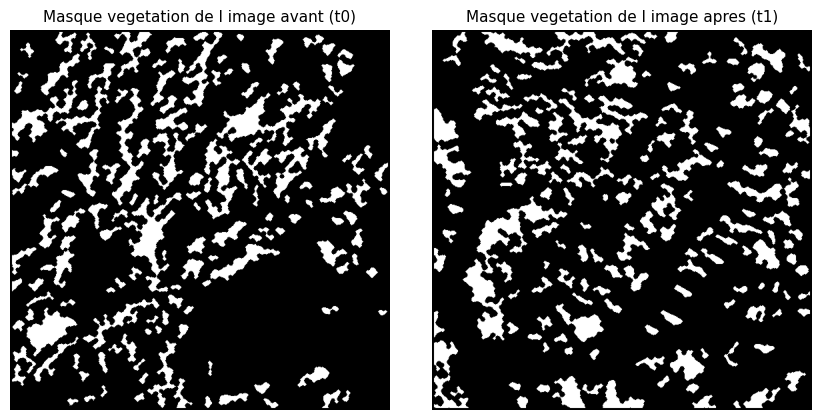

### Carte finale de changement

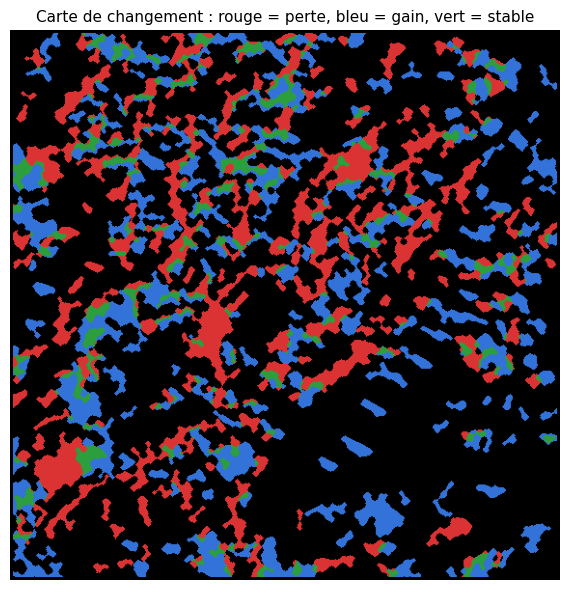

### Resume global de l analyse

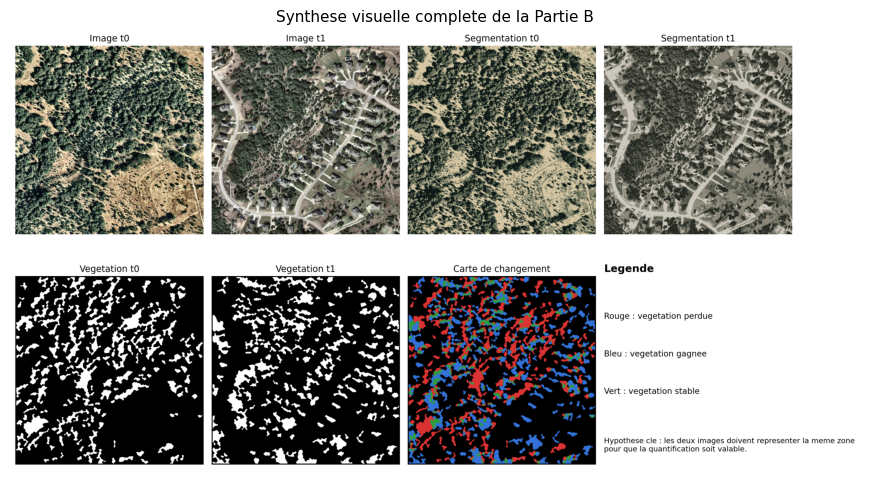

In [4]:
show_title('Masques de vegetation detectes')
show_pair(
    'outputs/vegetation_mask_t0.png',
    'outputs/vegetation_mask_t1.png',
    'Masque vegetation de l image avant (t0)',
    'Masque vegetation de l image apres (t1)',
    figsize=(8.6, 4.2),
)

show_title('Carte finale de changement')
show_single(
    'outputs/deforestation_map.png',
    'Carte de changement : rouge = perte, bleu = gain, vert = stable',
    figsize=(6.0, 6.0),
)

show_title('Resume global de l analyse')
show_single(
    'outputs/analysis_summary.png',
    'Synthese visuelle complete de la Partie B',
    figsize=(8.8, 6.5),
)


In [5]:
veg_t0_pct = metrics['vegetation_fraction_t0'] * 100
veg_t1_pct = metrics['vegetation_fraction_t1'] * 100
net_loss_pct = metrics['net_loss_ratio_formula'] * 100
net_delta_pts = veg_t1_pct - veg_t0_pct

display(Markdown(f'''
## Lecture des metriques de la Partie B

- **Vegetation dans l'image avant (t0)** : {veg_t0_pct:.2f}%
- **Vegetation dans l'image apres (t1)** : {veg_t1_pct:.2f}%
- **Variation nette** : {net_delta_pts:+.2f} points
- **Formule de perte nette du sujet** : {net_loss_pct:+.2f}%
- **Pixels de vegetation perdus** : {metrics['lost_pixels']}
- **Pixels de vegetation gagnes** : {metrics['gained_pixels']}
- **Changement net en pixels** : {metrics['net_change_pixels']:+d}

**Interpretation**

- si la formule de perte nette est positive, il y a une perte nette de vegetation
- si elle est negative, il y a un gain net de vegetation
- dans ce run, la quantification automatique indique donc un leger gain net de vegetation, malgre une impression visuelle de scene plus urbanisee
'''))

metrics



## Lecture des metriques de la Partie B

- **Vegetation dans l'image avant (t0)** : 18.38%
- **Vegetation dans l'image apres (t1)** : 18.85%
- **Variation nette** : +0.47 points
- **Formule de perte nette du sujet** : -2.58%
- **Pixels de vegetation perdus** : 45898
- **Pixels de vegetation gagnes** : 47437
- **Changement net en pixels** : +1539

**Interpretation**

- si la formule de perte nette est positive, il y a une perte nette de vegetation
- si elle est negative, il y a un gain net de vegetation
- dans ce run, la quantification automatique indique donc un leger gain net de vegetation, malgre une impression visuelle de scene plus urbanisee


{'total_pixels': 324900,
 'vegetation_pixels_t0': 59706,
 'vegetation_pixels_t1': 61245,
 'vegetation_fraction_t0': 0.1837673130193906,
 'vegetation_fraction_t1': 0.18850415512465374,
 'lost_pixels': 45898,
 'gained_pixels': 47437,
 'net_change_pixels': 1539,
 'net_loss_ratio_formula': -0.025776303889056378,
 'direct_loss_ratio': 0.7687334606237229,
 'image_t0': 'outputs/preprocessed_images/16_t0_preprocessed.png',
 'image_t1': 'outputs/preprocessed_images/17_t1_preprocessed.png',
 't0_label': 'etat avant',
 't1_label': 'etat apres',
 'feature_set': 'r, g, b, h, s, v, green_ratio, local_mean, local_variance',
 'vegetation_cluster_t0': 2,
 'vegetation_cluster_t1': 3,
 'vegetation_scores_t0': [0.3440137207508087,
  0.377610981464386,
  0.3846590220928192,
  0.356548547744751],
 'vegetation_scores_t1': [0.3369455635547638,
  0.3533119261264801,
  0.34196895360946655,
  0.3623400628566742],
 'n_clusters': 4,
 'summary_figure': 'outputs/analysis_summary.png',
 'interpretation_note': 'La car

## Comment lire les metriques et les sorties finales

Les masques de vegetation permettent de comparer directement l'image avant et l'image apres :
- le masque de `t0` montre les zones considerees comme vegetalisees dans l'etat initial
- le masque de `t1` montre les zones considerees comme vegetalisees dans l'etat final

La carte finale de changement se lit ainsi :
- rouge : vegetation perdue entre `t0` et `t1`
- bleu : vegetation gagnee entre `t0` et `t1`
- vert : vegetation stable

Les metriques se lisent en complement de cette carte :
- `vegetation_fraction_t0` et `vegetation_fraction_t1` donnent la proportion globale de vegetation avant et apres
- `lost_pixels` et `gained_pixels` donnent les pertes et gains locaux
- `net_loss_ratio_formula` donne le bilan global selon la formule demandee dans le sujet

Le point essentiel est de ne pas interpreter une seule metrique isolee. Il faut croiser :
- l'aspect visuel des images
- les masques de vegetation
- la carte de changement
- les pourcentages finaux


## Limites et points de vigilance

Les resultats de la Partie B doivent etre interpretes avec prudence pour plusieurs raisons :
- alignement possiblement imparfait entre les deux images
- effet du pretraitement sur la couleur et la texture
- sensibilite de la segmentation aux differences radiometriques
- image apres visuellement plus heterogene et plus urbanisee

Cela explique pourquoi l'intuition visuelle peut suggerer une perte de vegetation alors que la quantification automatique detecte ici un leger gain net.

Pistes d'amelioration :
- recalage geometrique plus strict entre `t0` et `t1`
- normalisation radiometrique entre les deux dates
- test de plusieurs valeurs de `k`
- superposition image originale + masque pour une validation plus fine
- comparaison avec une methode de segmentation plus robuste


## Conclusion globale du projet

Le projet met en place un pipeline complet, progressif et interpretable pour analyser l'evolution de la couverture du sol entre deux dates.

La **Partie A** montre que le pretraitement, le ratio vert et les features locales permettent deja de mettre en evidence des zones de changement et de preparer une lecture environnementale du probleme.

La **Partie B** va plus loin en proposant une segmentation structuree de la vegetation, une identification automatique du cluster vegetal, puis une quantification explicite de la vegetation avant et apres.

Au niveau visuel, l'image apres semble plus urbanisee, ce qui suggere intuitivement une perte de vegetation. Au niveau quantitatif, la segmentation ne confirme pas clairement cette hypothese sur ce run et donne au contraire un tres leger gain net de vegetation.

La conclusion la plus rigoureuse est donc la suivante :
- le pipeline est coherent et exploitable
- les sorties visuelles et les metriques sont bien organisees
- l'interpretation finale doit rester prudente a cause des limites de comparabilite entre les deux images

Autrement dit, le projet montre bien la valeur d'un pipeline justifie, mais aussi l'importance d'expliciter ses limites lorsque la lecture visuelle et la quantification ne racontent pas exactement la meme histoire.
